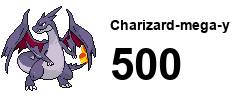

In [ ]:
import pypokedex
import requests
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO

def create_pokemon_image(pokemon_name, power, front = False, shiny_or_default = 'default', lines_left_top_right_bottom = (True,True,True,True)):
    blank_image = Image.new('RGB', (250, 98), (255, 255, 255))  # Create a blank image (250x98) with white background

    sprite_image = Image.new('RGB', (96, 96), (0, 0, 0)).convert("RGBA") # Default Sprite
    try: # Import the Sprite
        pokemon = pypokedex.get(name=pokemon_name.lower())
        if not front:
            try:
                sprite_url = pokemon.sprites.back[shiny_or_default]
                response = requests.get(sprite_url)
            except:
                sprite_url = pokemon.sprites.front[shiny_or_default]
                response = requests.get(sprite_url)
        else:
            sprite_url = pokemon.sprites.front[shiny_or_default]
            response = requests.get(sprite_url)
        sprite_image = Image.open(BytesIO(response.content)).convert("RGBA")  # Fetch the sprite imag
    except:
        pass

    sprite_image = sprite_image.resize((96, 96))  # Resize sprite if needed to fit the blank image (optional)
    blank_image.paste(sprite_image, (1, 1), sprite_image) # Paste the sprite on the left side of the blank image (use alpha for transparency)

    draw = ImageDraw.Draw(blank_image) # Prepare to add text
    try:     # Load bold font for the name and a larger font for the power number
        if len(pokemon_name) > 12:
            font_bold = ImageFont.truetype("arialbd.ttf", 14)  # Smaller font if the name is longer than 12 characters
        else:
            font_bold = ImageFont.truetype("arialbd.ttf", 24)  # Regular bold font for shorter names
        font_large = ImageFont.truetype("arialbd.ttf", 44)  # Larger bold font for power number
    except IOError:
        font_bold = ImageFont.load_default()  # Fallback to default font if custom font isn't available
        font_large = ImageFont.load_default()
    if len(pokemon_name) > 12:  # Add the Pokémon name to the right of the sprite
        draw.text((110, 17), pokemon_name, fill="black", font=font_bold)  # Position (110, 17)
    else:
        draw.text((110, 10), pokemon_name, fill="black", font=font_bold)  # Position (110, 10)
    draw.text((110, 40), str(power), fill="black", font=font_large)  # Add the power number below the name with larger font

    border_width = 1 # Draw lines
    image_width, image_height = blank_image.size
    if lines_left_top_right_bottom[1]:
        draw.line([(0, 0), (image_width, 0)], fill="black", width=border_width) #Draw top line
    if lines_left_top_right_bottom[3]:
        draw.line([(0, image_height - 1), (image_width, image_height - 1)], fill="black", width=border_width) # Draw bottom line
    if lines_left_top_right_bottom[0]:
        draw.line([(0, 0), (0, image_height)], fill="black", width=border_width) # Draw left line
    if lines_left_top_right_bottom[2]:
        draw.line([(image_width - 1, 0), (image_width - 1, image_height)], fill="black", width=border_width) # Draw right line

    return blank_image


# Example usage:
create_pokemon_image("Charizard-mega-y", 500,False, 'shiny', (False,False,False,False))
#create_pokemon_image("Pikachu", 222)

In [ ]:
import pypokedex
pypokedex.get('Hatenna')

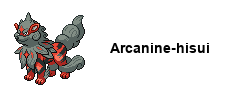

In [2]:
def create_pokemon_name_image(pokemon_name, front = True, shiny_or_default = 'default', lines_left_top_right_bottom = (True,True,True,True)):
    blank_image = Image.new('RGB', (250, 98), (255, 255, 255)) # Create a blank image (250x96) with white background

    sprite_image = Image.new('RGB', (96, 96), (0, 0, 0)).convert("RGBA")
    try:
        pokemon = pypokedex.get(name=pokemon_name.lower())
        if not front:
            try:
                sprite_url = pokemon.sprites.back[shiny_or_default]
                response = requests.get(sprite_url)
            except:
                sprite_url = pokemon.sprites.front[shiny_or_default]
                response = requests.get(sprite_url)
        else:
            sprite_url = pokemon.sprites.front[shiny_or_default]
            response = requests.get(sprite_url)
        sprite_image = Image.open(BytesIO(response.content)).convert("RGBA") # Fetch the sprite imag
    except:
        pass

    sprite_image = sprite_image.resize((96, 96)) # Resize sprite if needed to fit the blank image (optional)
    blank_image.paste(sprite_image, (1, 1), sprite_image) # Paste the sprite on the left side of the blank image (use alpha for transparency)
   
    draw = ImageDraw.Draw(blank_image)  # Prepare to add text
    try:
        if len(pokemon_name) > 12:
            font_bold = ImageFont.truetype("arialbd.ttf", 14)  # Smaller font if the name is longer than 12 characters
        else:
            font_bold = ImageFont.truetype("arialbd.ttf", 24)  # Regular bold font for shorter names
    except IOError:
        font_bold = ImageFont.load_default()  # Fallback to default font if custom font isn't available
    if len(pokemon_name) > 12: # Add the Pokémon name to the right of the sprite
        draw.text((110, 40), pokemon_name, fill="black", font=font_bold)  # Center the name vertically
    else:
        draw.text((110, 35), pokemon_name, fill="black", font=font_bold)  # Center the name vertically

    border_width = 1
    image_width, image_height = blank_image.size
    if lines_left_top_right_bottom[1]:
        draw.line([(0, 0), (image_width, 0)], fill="black", width=border_width) #Draw top line
    if lines_left_top_right_bottom[3]:
        draw.line([(0, image_height - 1), (image_width, image_height - 1)], fill="black", width=border_width) # Draw bottom line
    if lines_left_top_right_bottom[0]:
        draw.line([(0, 0), (0, image_height)], fill="black", width=border_width) # Draw left line
    if lines_left_top_right_bottom[2]:
        draw.line([(image_width - 1, 0), (image_width - 1, image_height)], fill="black", width=border_width) # Draw right line

    return blank_image

create_pokemon_name_image('Arcanine-hisui', front = False, lines_left_top_right_bottom= (False,False,False,False))

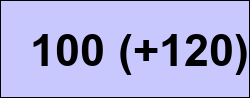

In [3]:
from PIL import Image, ImageDraw, ImageFont

def create_text_image(text, background_color,lines_left_top_right_bottom = (True,True,True,True)):
    image = Image.new('RGB', (250, 98), background_color) #  Create a blank image (250x96) with the specified background color

    draw = ImageDraw.Draw(image) # Prepare to add text
    try: # Load bold font for the text
        if len(text) > 11:
            font = ImageFont.truetype("arialbd.ttf", 24)  # Smaller font if text is longer than 8 characters
        else:
            font = ImageFont.truetype("arialbd.ttf", 45)  # Regular font for short text
    except IOError:
        font = ImageFont.load_default()  # Fallback to default font if custom font isn't available
    position = (30, 25)  # Add the text at a fixed position
    draw.text(position, text, fill="black", font=font)

    border_width = 1
    image_width, image_height = image.size
    if lines_left_top_right_bottom[1]:
        draw.line([(0, 0), (image_width, 0)], fill="black", width=border_width) #Draw top line
    if lines_left_top_right_bottom[3]:
        draw.line([(0, image_height - 1), (image_width, image_height - 1)], fill="black", width=border_width) # Draw bottom line
    if lines_left_top_right_bottom[0]:
        draw.line([(0, 0), (0, image_height)], fill="black", width=border_width) # Draw left line
    if lines_left_top_right_bottom[2]:
        draw.line([(image_width - 1, 0), (image_width - 1, image_height)], fill="black", width=border_width) # Draw right line

    return image

# Example usage:
create_text_image("100 (+120)", (200, 200, 255))  # Light blue background


In [4]:
from PIL import Image, ImageDraw, ImageFont
import pandas as pd
import random

# Assuming create_text_image and create_pokemon_image functions are defined as needed.

def create_pokemon_collage(df, type = 'gym', path=None, enemy_powers=None):

    def randomly_shiny():
        if random.randint(0,1023) == 1:
            return "shiny"
        else:
            return "default"
        
    image_width = 250 # Assuming all images have the same size (250x98)
    image_height = 98

    num_rows, num_cols = df.shape # Create a blank collage image with a grid layout (grid_size is a tuple of (rows, cols))
    collage_width = (num_cols-1) * image_width
    collage_height = (num_rows+1) * image_height
    collage_image = Image.new('RGB', (collage_width, collage_height), (255, 255, 255))  # White background
    
    # Crea prima colonna, squadra.
    name_image = create_text_image(f'{type.title()} →',(255,255,255),(False,False,True,True))
    collage_image.paste(name_image, (0,0))
    for index, (pokemon_name, power) in enumerate(zip(df['Pokemon'].tolist(), df['Potenza Base'].tolist())):
        name_position = (0, (index+1) * image_height) # Position for Pokémon name
        name_image = create_pokemon_image(pokemon_name, power, front = False, shiny_or_default = 'default', lines_left_top_right_bottom = (False,False,True,False))
        collage_image.paste(name_image, name_position)

    # Crea le altre colonne
    for col in range(2, num_cols):
        position = ((col-1) * image_width, 0)
        column_name = df.columns[col]  # Get column name (e.g., "Yanma (195)")
        if type == 'lega':
            pokemon_name, power = column_name.split(' ')
            power = int(power.replace('(','').replace(')',''))
            individual_image = create_pokemon_image(pokemon_name,power,True,randomly_shiny(),(False,False,False,True))  # Create the Pokémon image
        else:
            try: # Fixa i pokemon delle palestre tipo (Geodude, Geodude 2, Geodude 3)
                pokemon_name = column_name.split(' ')[0]
                print(pokemon_name)
            except:
                pokemon_name = column_name
            individual_image = create_pokemon_name_image(pokemon_name,True,randomly_shiny(),lines_left_top_right_bottom = (False,False,False,True))  # Create the Pokémon image
        collage_image.paste(individual_image, position)
        for index in range(num_rows):
            scaled_power = int(df[column_name][index].split(' ')[0].replace('(','').replace(')',''))
            position = ((col-1) * image_width, (index+1) * image_height)
            if type == 'lega':
                if scaled_power > power:
                    bg = (99, 238, 99)
                else:
                    bg = (255,255,255)
            elif type == 'encounter':
                try: #Se enemy_power = None o corto almeno non si blocca
                    if scaled_power > enemy_powers[0]:
                        bg = (255, 111, 111) # Red
                        if scaled_power > enemy_powers[1]:
                            bg = (255, 255, 111) # Yellow
                            if scaled_power > enemy_powers[col]: # nel caso encounter, enemy_powers è [bassa,media,boss1,boss2,boss3 ...],l'indice col ci fa un grand favore partendo da 2
                                bg = (99, 238, 99) # Green
                    else:
                        bg = (255,255,255)
                except:
                    bg = (0,0,0)
            else:
                try: #Se enemy_power = None o corto almeno non si blocca
                    if scaled_power > enemy_powers[0]:
                        bg = (255, 111, 111) # Red
                        if scaled_power > enemy_powers[1]:
                            bg = (255, 255, 111) # Yellow
                            if scaled_power > enemy_powers[2]:
                                bg = (99, 238, 99) # Green
                    else:
                        bg = (255,255,255)
                except:
                    bg = (0,0,0)

            text_image = create_text_image(df[column_name][index], bg,(False,False,False,False))  # White text on blue
            collage_image.paste(text_image, position)
        
    # Save or return the final collage image
    if path:
        collage_image.save(path)
    return collage_image

# Example usage
c = create_pokemon_collage(df,type= 'gym',enemy_powers= [400,415,430,600,450,500,416,500])
c.show()


NameError: name 'df' is not defined

In [ ]:
import pandas as pd

# Define the data as a dictionary
data = {
    "Pokemon": ["Swampert", "Donphan", "Donphan", "Salamence", "Regirock", "Latios", "Registeel", "Regice", "Kyogre"],
    "Potenza Base": [444, 333, 111, 888, 333, 438, 534, 441, 598],
    "Yanma": ["490 (-40)", "415 (-40)", "425 (0)", "642 (60)", "605 (100)", "398 (-40)", "574 (40)", "481 (40)", "598 (0)"],
    "Cacnea": ["410 (-120)", "395 (-60)", "365 (-60)", "662 (80)", "465 (-40)", "458 (20)", "554 (20)", "481 (40)", "538 (-60)"],
    "Araquanid": ["490 (-40)", "395 (-60)", "425 (0)", "662 (80)", "505 (0)", "418 (-20)", "534 (0)", "421 (-20)", "598 (0)"],
    "Alcremie": ["530 (0)", "455 (0)", "425 (0)", "502 (-80)", "505 (0)", "358 (-80)", "594 (60)", "441 (0)", "598 (0)"],
    "Farfetchd": ["530 (0)", "455 (0)", "425 (0)", "582 (0)", "525 (20)", "438 (0)", "554 (20)", "441 (0)", "598 (0)"],
}

# Create the DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
display(df)
print(df.shape)

,Pokemon,Potenza Base,Yanma,Cacnea,Araquanid,Alcremie,Farfetchd
0,Swampert,444,490 (-40),410 (-120),490 (-40),530 (0),530 (0)
1,Donphan,333,415 (-40),395 (-60),395 (-60),455 (0),455 (0)
2,Donphan,111,425 (0),365 (-60),425 (0),425 (0),425 (0)
3,Salamence,888,642 (60),662 (80),662 (80),502 (-80),582 (0)
4,Regirock,333,605 (100),465 (-40),505 (0),505 (0),525 (20)
5,Latios,438,398 (-40),458 (20),418 (-20),358 (-80),438 (0)
6,Registeel,534,574 (40),554 (20),534 (0),594 (60),554 (20)
7,Regice,441,481 (40),481 (40),421 (-20),441 (0),441 (0)
8,Kyogre,598,598 (0),538 (-60),598 (0),598 (0),598 (0)


(9, 7)


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import pypokedex
import requests
from io import BytesIO

def create_custom_pokemon_image(pokemon_name):
    # Load the Pokémon sprite using pypokedex
    pokemon = pypokedex.get(name=pokemon_name.lower())  # Convert name to lowercase for pypokedex
    sprite_url = pokemon.sprites.front['default']
    
    # Fetch the sprite image
    response = requests.get(sprite_url)
    sprite_image = Image.open(BytesIO(response.content)).convert("RGBA")  # Ensure transparency is preserved
    sprite_image = sprite_image.resize((96*5, 96*5))  # Resize sprite to 96x96

    # Image dimensions
    image_width = 96*5 + 4
    padding = 2
    text_size = 30
    line_height = 2

    # Calculate the total image height dynamically based on the text and sprite elements
    image_height = (
        padding * 2 +  # Vertical lines on both sides
        line_height +  # Top black line
        text_size +    # 'Nome' text
        line_height +  # After 'Nome' black line
        sprite_image.height +  # Sprite height (96px)
        line_height +  # After sprite black line
        text_size +    # 'Tipo' text
        line_height +  # After 'Tipo' black line
        text_size +    # 'Potenza' text
        line_height +  # After 'Potenza' black line
        text_size +    # 'Livello' text
        line_height +  # After 'Livello' black line
        text_size +    # 'Livello Evo' text
        line_height    # After 'Livello Evo' black line
    )
    print(image_height)

    # Create the blank image with white background
    image = Image.new('RGB', (image_width, image_height), (255, 255, 255))

    # Initialize drawing
    draw = ImageDraw.Draw(image)

    # Load the bold font
    try:
        font_bold = ImageFont.truetype("arialbd.ttf", text_size)  # Bold font, size 40
    except IOError:
        font_bold = ImageFont.load_default()

    # Start drawing the elements

    # Vertical lines (2 px)
    draw.line([(padding, 0), (padding, image_height)], fill="black", width=2)  # Left line
    draw.line([(image_width - padding, 0), (image_width - padding, image_height)], fill="black", width=2)  # Right line

    # Top black line
    y_offset = padding
    draw.line([(padding, y_offset), (image_width - padding, y_offset)], fill="black", width=line_height)

    # 'Nome' text
    y_offset += line_height
    draw.text((padding + 10, y_offset), "Nome", fill="black", font=font_bold)

    # After 'Nome' black line
    y_offset += text_size
    draw.line([(padding, y_offset), (image_width - padding, y_offset)], fill="black", width=line_height)

    # Pokémon sprite (aligned 2 pixels from the line)
    y_offset += line_height
    image.paste(sprite_image, (padding + 2, y_offset), sprite_image)

    # After sprite black line
    y_offset += sprite_image.height
    draw.line([(padding, y_offset), (image_width - padding, y_offset)], fill="black", width=line_height)

    # 'Tipo' text
    y_offset += line_height
    draw.text((padding + 10, y_offset), "Tipo", fill="black", font=font_bold)

    # After 'Tipo' black line
    y_offset += text_size
    draw.line([(padding, y_offset), (image_width - padding, y_offset)], fill="black", width=line_height)

    # 'Potenza' text
    y_offset += line_height
    draw.text((padding + 10, y_offset), "Potenza", fill="black", font=font_bold)

    # After 'Potenza' black line
    y_offset += text_size
    draw.line([(padding, y_offset), (image_width - padding, y_offset)], fill="black", width=line_height)

    # 'Livello' text
    y_offset += line_height
    draw.text((padding + 10, y_offset), "Livello", fill="black", font=font_bold)

    # After 'Livello' black line
    y_offset += text_size
    draw.line([(padding, y_offset), (image_width - padding, y_offset)], fill="black", width=line_height)

    # 'Livello Evo' text
    y_offset += line_height
    draw.text((padding + 10, y_offset), "Livello Evo", fill="black", font=font_bold)

    # After 'Livello Evo' black line
    y_offset += text_size
    draw.line([(padding, y_offset), (image_width - padding, y_offset)], fill="black", width=line_height)

    # Return the final image
    return image

# Example usage
image = create_custom_pokemon_image('Charizard')
image.show()


648


In [ ]:
print('ciao')

ciao
